# 第10课 · 一个数字量出“有多像”——点积（dot product）、余弦相似度与投影（projection）

**学习目标**
1. 会手算点积，并理解 `a·b = |a||b|cosθ`
2. 实现 `cosine_similarity(a, b)`（方向有多像，与长度无关）
3. 会算正交投影：影子有多长、投影向量长什么样

**为什么对 Aurora 重要**：`dft()` 里每个频点 `X[k]` 就是信号与复指数序列的点积。  
（以后注意力机制里的 QK 打分也是同一家族——L83 再展开，本课先把点积本身钉牢。）

← **上一课**　[L09 · 向量代数](L09_vectors.ipynb)

> 上节课学习了 **向量代数**：加法、标量乘法与线性组合，NumPy 实现 + 几何意义。  
> 本课将探讨 **点积与投影**。

## 本课剧情：音乐推荐背后的数学

Spotify 是怎么知道你会喜欢下一首歌的？

它把每首歌描述成一个向量（genre, tempo, energy, ...），然后找出和你听过的歌**方向最接近**的那首。方向的"接近程度"用**点积**来测量。

点积 `a·b = Σaᵢbᵢ`，把两个向量压缩成一个数：
- **正数** → 两个向量大体同向（你喜欢电子音乐，它推类似的）
- **零** → 完全垂直（两首歌毫无共同点）
- **负数** → 相反方向（你喜欢古典，它给了重金属）

但问题来了：一首 10 分钟的长歌，能量数值更大——即使风格很不同，点积也可能很高。

解法：除以两首歌各自的"能量大小"（范数），把点积**归一化**到 [-1, 1]。这就是**余弦相似度**（cosine similarity）——跟向量长度无关，只看方向。

本课实现 `cosine_similarity(a, b)` 和理解正交投影（投影 = 点积 / 模）。

## 1. 点积的定义

两个向量 `a = [a₁, a₂, ..., aₙ]` 和 `b = [b₁, b₂, ..., bₙ]`，点积是：

```
a · b = a₁b₁ + a₂b₂ + ... + aₙbₙ = Σᵢ aᵢbᵢ
```

手算例子：a = [1, 2, 3]，b = [4, 5, 6]

```
1×4 + 2×5 + 3×6 = 4 + 10 + 18 = 32
```

几何解读：`a·b = |a| · |b| · cos(θ)`，其中 θ 是两向量夹角。

这给点积第二种理解方式：**|a| · |b| · cos(θ) = 对长度归一化后的"方向一致性"乘以两者的长度**。

DFT 里，`X[k] = Σ x[n] · e^{-2πikn/N}` 就是信号 x 与第 k 个旋转因子的点积——每个频率分量的"得分"。

> 💡 `e^{-2πikn/N}` 是复数，点积怎么跟复数打交道，本课稍后（参数实验之后）会配合具体例子专门解释——这里先记住：它和上面这套"逐元素相乘再求和"是同一套逻辑，只是其中一个向量换成了复数。

## 追问：为什么 a·b 会等于 |a|·|b|·cos(θ)？——一个"拔河"的故事

想象两根绳子都从你脚下的同一点拉出去，一根指向东偏北一点（向量 a），一根指向东偏南一点（向量 b）。两根绳子之间夹着一个角度 θ。你想知道：这两根绳子"往同一个方向使劲"的程度有多大？

直接盯着"点积 = 对应位置相乘再相加"这个算法定义，你看不出它和"角度"有什么关系——这正是很多同学卡住的地方。我们从**距离**入手，搭一座桥。

**第一步：画出第三条边。** 把 a 和 b 的箭头都从原点画出来，它们的"差" a − b 也是一个向量，正好是连接两个箭头尖端的那条边，和 a、b 一起组成一个三角形，夹角就是 θ。

**第二步：用两种方法算这条边的长度平方 |a−b|²。**

方法 A —— 纯代数（逐分量展开，对任意维度都成立）：
```
|a - b|² = Σᵢ (aᵢ - bᵢ)²
         = Σᵢ aᵢ² - 2Σᵢ aᵢbᵢ + Σᵢ bᵢ²
         = |a|² + |b|² - 2 (a·b)
```
这一步没有用到任何几何知识，纯粹是括号展开、合并同类项。

方法 B —— 几何定理（三角形里边和角的关系）：
初中学过的**余弦定理**告诉我们，三角形一条边的平方 = 另两边平方和 − 2×两边之积×夹角余弦：
```
|a - b|² = |a|² + |b|² - 2 |a||b| cos(θ)
```

**第三步：两种算法算的是同一个数，那就可以划等号。**
```
|a|² + |b|² - 2(a·b)  =  |a|² + |b|² - 2|a||b|cos(θ)
```
两边同时减去 `|a|² + |b|²`，再除以 −2：
```
a·b = |a| · |b| · cos(θ)
```

这就是桥梁：**逐元素相乘求和**（左边，代数定义）和**长度 × 长度 × 夹角余弦**（右边，几何定义），算的是同一件事，只是从两个不同角度看而已——所以垂直时 cos(θ)=0，点积自然也是 0；这不是巧合，是同一个等式的两种写法。

**为什么是 cos 不是 sin？** 因为这条推导路径走的是"边长"（距离），而余弦定理正是把"边长"和"夹角"连起来的定理；sin 出现在"面积"相关的公式里（比如三角形面积、叉积），量的是"两条边张开成的面"，不是这里要算的东西。

**1000 维的向量还有"夹角"吗？** 有——注意第二步的方法 A 完全不需要画图，`Σ(aᵢ-bᵢ)²` 对 3 维、1000 维都能直接算出一个数，不需要眼睛去"看"夹角。既然方法 A 和方法 B 算的是同一个数，我们就可以**反过来用这个等式去定义**高维向量的夹角：
```
cos(θ) := (a·b) / (|a| · |b|)
```
θ 不再是"用眼睛看出来的角度"，而是"由这个公式算出来的角度"——这也是"余弦相似度"这个名字的来历。下面用一个具体的例子把这套推导跑一遍。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


a = [4. 1.], b = [1. 3.]
方法A |a-b|² (纯代数展开)   = 13.0000
方法B |a-b|² (余弦定理代入) = 13.0000
两种算法吻合 ✅ —— 这正是 a·b = |a||b|cos(θ) 成立的原因


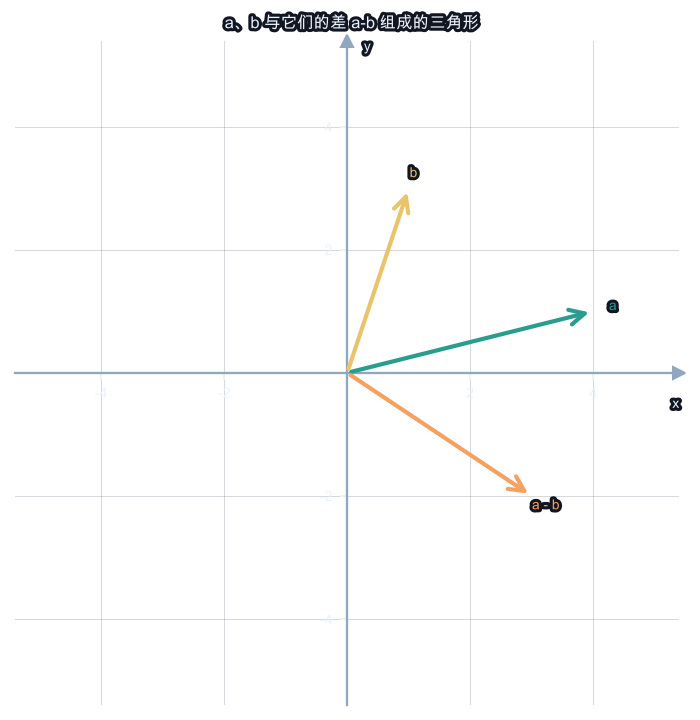

In [2]:
import numpy as np
from aurora.laviz import style, arrows2d

va = np.array([4.0, 1.0])
vb = np.array([1.0, 3.0])

# 方法 A：纯代数展开，逐分量算 |a-b|²
lhs = np.sum((va - vb) ** 2)

# 方法 B：先从点积反解出夹角 theta，再代入余弦定理
cos_theta = np.dot(va, vb) / (np.linalg.norm(va) * np.linalg.norm(vb))
theta = np.arccos(cos_theta)
rhs = (np.linalg.norm(va) ** 2 + np.linalg.norm(vb) ** 2
       - 2 * np.linalg.norm(va) * np.linalg.norm(vb) * np.cos(theta))

print(f"a = {va}, b = {vb}")
print(f"方法A |a-b|² (纯代数展开)   = {lhs:.4f}")
print(f"方法B |a-b|² (余弦定理代入) = {rhs:.4f}")
assert np.isclose(lhs, rhs), "两种算法应给出同一个数"
print("两种算法吻合 ✅ —— 这正是 a·b = |a||b|cos(θ) 成立的原因")

style()
arrows2d([va, vb, va - vb], ['a', 'b', 'a - b'],
         title='a、b 与它们的差 a-b 组成的三角形')

## 符号入口：先看形状，再看运算

点积的两个输入都必须是同维向量 `(n,)`，输出是标量。每次遇到新运算，先确认输入的形状匹配，再写计算。

In [3]:
import numpy as np
a = np.array([1.0, 2.0, 3.0])
b = np.array([4.0, 5.0, 6.0])
print('逐元素相乘:', a * b)        # [4 10 18]
print('点积(求和):', np.dot(a, b)) # 32
print('也可写作 a @ b =', a @ b)

逐元素相乘: [ 4. 10. 18.]
点积(求和): 32.0
也可写作 a @ b = 32.0


## 动手观察：两个向量，三种角度关系

运行下面的代码，注意 `np.dot(a, b)` 的正负号如何随两向量夹角变化：方向相同时为正，垂直时为零，反向时为负。这就是点积作为“对齐程度”的直观含义。

In [4]:
import numpy as np

# 三种角度关系：同向、正交、反向
a = np.array([1., 0.])
cases = [
    ("同向  cosθ = +1", np.array([ 2.,  0.])),
    ("正交  cosθ =  0", np.array([ 0.,  1.])),
    ("反向  cosθ = -1", np.array([-1.,  0.])),
]
print(f"固定向量 a = {a}")
for label, b in cases:
    dot = np.dot(a, b)
    cos = dot / (np.linalg.norm(a) * np.linalg.norm(b))
    print(f"  {label}:  a·b = {dot:+.2f},  cosine = {cos:+.2f}")


固定向量 a = [1. 0.]
  同向  cosθ = +1:  a·b = +2.00,  cosine = +1.00
  正交  cosθ =  0:  a·b = +0.00,  cosine = +0.00
  反向  cosθ = -1:  a·b = -1.00,  cosine = -1.00


> **📌 L12 预告**：下方单元格演示矩阵对向量的缩放变换，属于 L12（矩阵变换）预告内容，现在只需观察形状，L12 将完整推导。


In [5]:
import numpy as np

v = np.array([3.0, 4.0])
A = np.array([[2.0, 0.0],
              [0.0, 0.5]])

print('v =', v, 'shape =', v.shape)
print('A =')
print(A)
print('A shape =', A.shape)
print('A @ v =', A @ v)
print('向量长度 ||v|| =', np.linalg.norm(v))


v = [3. 4.] shape = (2,)
A =
[[2.  0. ]
 [0.  0.5]]
A shape = (2, 2)
A @ v = [6. 2.]
向量长度 ||v|| = 5.0


## 代码实验：遍历几对向量，观察余弦相似度如何响应方向关系

依次计算几对向量的余弦相似度：完全相同 → +1，正交（orthogonal）→ 0，锐角 → 接近 +1。注意结果只由**方向**决定，与向量长度无关——这正是余弦相似度对点积做归一化的意义。

In [6]:
import numpy as np

# 余弦相似度 = 点积 ÷ 两向量的模之积
pairs = [
    (np.array([1.,0.]), np.array([1.,0.])),   # 完全相同
    (np.array([1.,0.]), np.array([0.,1.])),   # 正交
    (np.array([1.,1.]), np.array([1.,-1.])),  # 正交
    (np.array([3.,4.]), np.array([4.,3.])),   # 锐角
]
for a, b in pairs:
    cos = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
    print(f'cos({a}, {b}) = {cos:+.4f}')


cos([1. 0.], [1. 0.]) = +1.0000
cos([1. 0.], [0. 1.]) = +0.0000
cos([1. 1.], [ 1. -1.]) = +0.0000
cos([3. 4.], [4. 3.]) = +0.9600


## 2. 余弦相似度：方向有多一致（-1~1，越接近1越像）

`cos = (a·b) / (|a| · |b|)`，其中 `|a|` 是向量长度（下一课细讲）。

### 插一句：`|a|` 到底是什么？（不用等到下一课）

上面的公式里冒出一个新符号 `|a|`。多本教材里也写成 `‖a‖`（两条竖线），代码里对应的是 `np.linalg.norm(a)`——**这三种写法说的是同一件事**：向量的"长度"，正式名字叫**范数（norm）**。

为什么长度要用"平方和再开根号"，而不是直接把分量加起来？想想你在地图上量两点间的直线距离：如果横向差了 3 格、纵向差了 4 格，直线距离不是 3+4=7，而是勾股定理算出来的 `√(3²+4²) = 5`。向量的长度是同一个道理的推广——只不过从 2 个分量（横、纵）扩展到 n 个分量：

```
|a| = ‖a‖ = np.linalg.norm(a) = √(a₁² + a₂² + ... + aₙ²)
```

例如 `a = [1, 2, 3]`：`|a| = √(1² + 2² + 3²) = √14 ≈ 3.742`。直接加起来的 `1+2+3=6` 之所以不对，是因为分量可能有正有负（比如 a=[3,-4]，长度应该是 5，而不是 3+(-4)=-1），平方能保证每一项都不为负，再开根号才能还原回"长度"这个量纲。

本课先用到 `|a|`；L11 会专门展开讲它的完整定义（L1、L2、∞ 范数）和数学性质，这里只需要记住：**三种写法，一个意思，算法是"平方和开根号"**。

In [7]:
import numpy as np

a = np.array([1.0, 2.0, 3.0])

manual_norm = np.sqrt(np.sum(a ** 2))   # 逐分量平方，求和，再开根号
builtin_norm = np.linalg.norm(a)         # NumPy 内置函数，算的是同一件事

print(f"手动计算 √(1²+2²+3²) = {manual_norm:.4f}")
print(f"np.linalg.norm(a)    = {builtin_norm:.4f}")
assert np.isclose(manual_norm, builtin_norm)
print("两者一致 ✅ —— |a| = ‖a‖ = np.linalg.norm(a) 说的是同一件事")

手动计算 √(1²+2²+3²) = 3.7417
np.linalg.norm(a)    = 3.7417
两者一致 ✅ —— |a| = ‖a‖ = np.linalg.norm(a) 说的是同一件事


## 3. ✏️ 你的任务：实现 `cosine_similarity`

**推理路线**：
1. 公式 `cos = (a·b) / (|a|·|b|)` 把点积除以两个向量的长度之积，消掉大小只留方向——无论向量多长，同向结果始终为 1。
2. 分子是点积 `Σ aᵢbᵢ`，直接用 `np.dot(a, b)` 计算。
3. 分母 `|a|·|b|` 是两个 L2 范数之积（下节推导）；暂时用 `np.linalg.norm()`。
4. 边界验证：同向向量 → 1；垂直向量 → 0；反向向量 → -1。

**参考输入输出**：`a=[1,2,3]`，`b=[4,5,6]` → 点积 = 32，|a|=√14≈3.742，|b|=√77≈8.775，余弦 ≈ **0.974**

> 💡 需要提示？完成练习后可参考 `solutions/` 目录中的参考实现。


### 写 `cosine_similarity` 前明确三件事

- 输入：`a`、`b`，形状均为 `(n,)`，维度必须相同
- 关键步骤：分子 `np.dot(a, b)`，分母 `np.linalg.norm(a) * np.linalg.norm(b)`
- 返回：标量，范围 [-1, 1]；垂直向量应得 0，同向应得 1

### 插一句：为什么零向量要专门报错？

代码要求："若任一向量为零向量（模为 0），raise ValueError"。这不是为了刁难你，而是数学上真的算不出结果。

公式是 `cos = (a·b) / (|a| · |b|)`。如果 `a` 是零向量 `[0, 0, ..., 0]`，那么 `|a| = 0`，分母就变成了 0——而"除以 0"在数学上没有定义（不是"无穷大"，是"没有答案"）。Python/NumPy 遇到 `0.0 / 0.0` 不会立刻报错，而是悄悄给你一个 `nan`（not a number），如果不提前拦住，程序会带着这个"坏数字"继续跑，真正出问题的地方却在很远之后，很难排查。

**现实中真的会遇到零向量吗？** 会。比如一首刚上架、还没有人听过也没被标注任何风格标签的新歌，它的特征向量可能就是全 0（推荐系统里这叫"冷启动"问题）；或者上游的数据管道出了故障，把某首歌的特征意外清空成了 0。这时候"这首歌跟谁更像"这个问题本身就没有意义——**没有方向，就没有"像不像"可言**。与其让程序悄悄算出一个 `nan` 然后在几十行代码之后才崩溃，不如现在就报错，把问题暴露在源头。下面的代码演示一下不做检查会发生什么：

In [8]:
import numpy as np

zero = np.array([0.0, 0.0, 0.0, 0.0])
song = np.array([5.0, 0.0, 3.0, 0.0])

with np.errstate(invalid='ignore', divide='ignore'):
    silent_result = np.dot(zero, song) / (np.linalg.norm(zero) * np.linalg.norm(song))
print(f"如果不做零向量检查，直接计算会悄悄得到：{silent_result}")
print("← 这就是没有拦截零向量的后果：nan 会带着错误一路传下去，很久之后才在别处报错")

如果不做零向量检查，直接计算会悄悄得到：nan
← 这就是没有拦截零向量的后果：nan 会带着错误一路传下去，很久之后才在别处报错


In [9]:
def cosine_similarity(a, b):
    """
    返回向量 a 与 b 的余弦相似度，范围 [-1, 1]。
    若任一向量为零向量（模为 0），raise ValueError。
    """
    # ✏️ TODO: 实现余弦相似度
    # 提示：分子 np.dot(a, b)，分母 np.linalg.norm(a) * np.linalg.norm(b)
    # 零向量处理：if np.linalg.norm(a) == 0 or np.linalg.norm(b) == 0: raise ValueError("...")
    raise NotImplementedError("请实现 cosine_similarity")


In [10]:
song1 = np.array([5.0, 0.0, 3.0, 0.0])  # 假装是歌曲特征向量
song2 = np.array([4.0, 0.0, 2.0, 0.0])  # 和 song1 很像
song3 = np.array([0.0, 5.0, 0.0, 4.0])  # 风格不同

try:
    print("sim(1,2) =", round(cosine_similarity(song1, song2), 3), "(应接近 1, 很像)")
    print("sim(1,3) =", round(cosine_similarity(song1, song3), 3), "(应接近 0, 不像)")
    assert abs(cosine_similarity(song1, 2 * song1) - 1.0) < 1e-12, "同向向量余弦相似度应精确 = 1"
    assert cosine_similarity(song1, song2) > 0.9, "同类歌曲相似度应 > 0.9"
    assert abs(cosine_similarity(song1, song3)) < 1e-10, "song1⊥song3 相似度应精确为 0"
    assert cosine_similarity(song1, song2) > cosine_similarity(song1, song3)
    # 边界：零向量应触发 ValueError
    try:
        cosine_similarity(np.zeros(4), song1)
        assert False, "零向量应触发 ValueError"
    except ValueError:
        print("✅ 零向量边界：正确触发 ValueError")
    print("\n✅ 全部通过：你做出了推荐系统的核心度量。")
except (NotImplementedError, TypeError) as e:
    print(f"⚠️  尚未实现：{e}\n请在上方 cell 填写 cosine_similarity 函数体。")


⚠️  尚未实现：请实现 cosine_similarity
请在上方 cell 填写 cosine_similarity 函数体。


**🔗 Aurora 连接**：Music Core 的"猜你喜欢"= 找余弦相似度最高的歌。DFT 里 `X[k]` = 信号 · 第 k 个频率的复指数，也是点积。

## 🎨 图示：外积（→秩1矩阵）

内积 a·b = 标量（下方打印）；外积 a⊗b = 秩1矩阵（下方热力图）。

内积 a·b = 32  （标量，压缩成一个数）
外积 a⊗b = 秩1矩阵（展开成矩阵，见图示）：


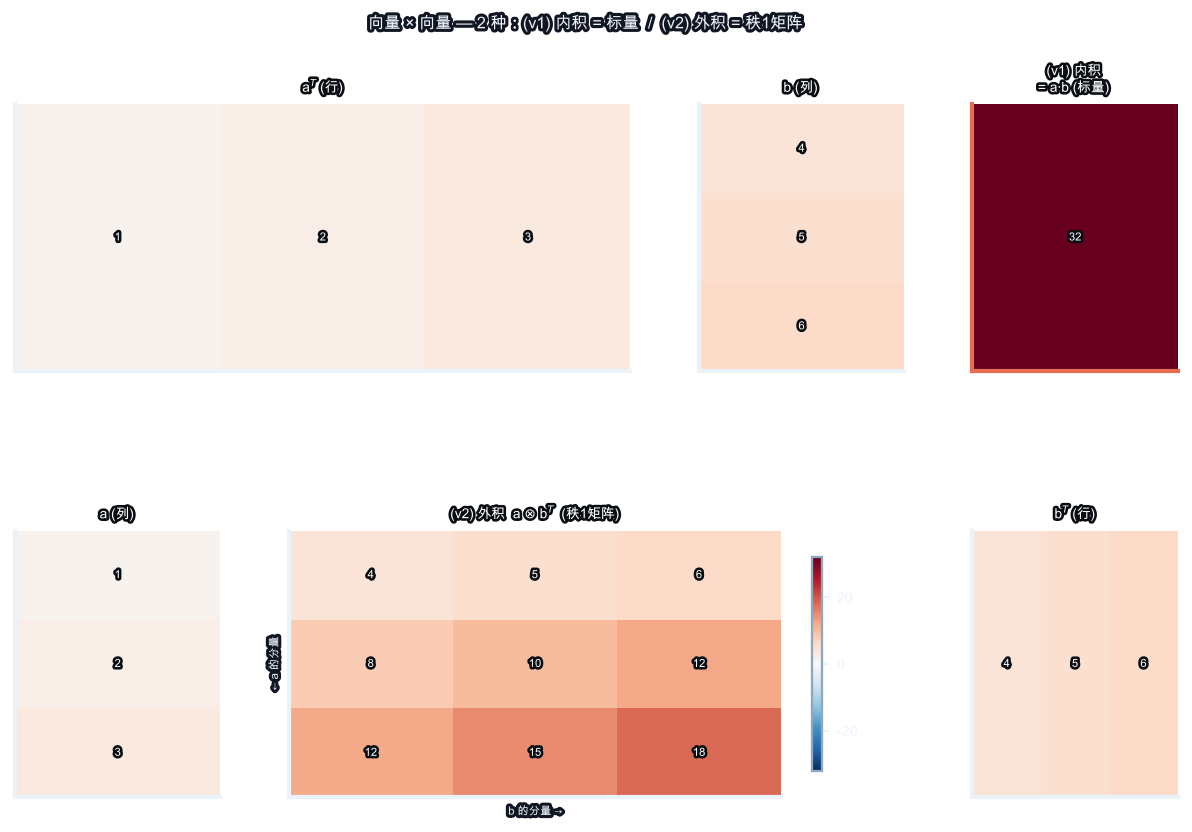

In [11]:
import numpy as np
from aurora.laviz import style, vec_times_vec
style()
a_vis, b_vis = [1, 2, 3], [4, 5, 6]
inner = int(sum(x*y for x, y in zip(a_vis, b_vis)))
print(f"内积 a·b = {inner}  （标量，压缩成一个数）")
print("外积 a⊗b = 秩1矩阵（展开成矩阵，见图示）：")
vec_times_vec(a_vis, b_vis);


### 追问："内积"和"外积"为什么叫这两个名字？"秩 1 矩阵"又是什么？

**为什么一个叫"内"、一个叫"外"？** 可以把它们想成两个方向相反的动作：

- **内积**（点积就是内积的一种）：两个向量往"里"收缩，压缩成一个数字——两条信息变成了一条，维度往内收。
- **外积**：两个向量往"外"展开，铺成了一整个矩阵——一条信息乘出了一大片，维度往外扩。

一个是"收"，一个是"扩"，方向正好相反，这就是"内""外"两个字的来历。

**"秩 1 矩阵"是什么意思？** "秩"（rank）粗略地说，是一个矩阵里"独立方向"的个数——矩阵的每一行（或每一列）里，真正带来新信息的方向有多少种。看下面热力图对应的矩阵：外积 `a⊗b` 的每一行，都只是向量 `b` 乘上一个不同的倍数（第 1 行是 `a₁×b`，第 2 行是 `a₂×b`，……）。所有行说的都是"b 这个方向"的事，只是倍数不同——整个矩阵里其实只藏着"一个方向"的信息，这就是为什么外积永远是**秩 1**（rank-1）矩阵，不管 a、b 有多少维。矩阵的"秩"在 L12（矩阵变换）会有完整定义，这里先建立一个直觉：**秩 1 = 矩阵里的所有行都只是同一个向量的不同倍数**。下面验证一下：

In [12]:
import numpy as np

a_vis, b_vis = np.array([1, 2, 3]), np.array([4, 5, 6])
outer = np.outer(a_vis, b_vis)
print("外积矩阵 a⊗b =")
print(outer)
print("\n每一行是不是 b 的倍数？")
for i, row in enumerate(outer):
    print(f"  第{i+1}行 {row} = {a_vis[i]} × {b_vis}")
print(f"\nnp.linalg.matrix_rank(outer) = {np.linalg.matrix_rank(outer)}  ← 验证确实是秩 1")

外积矩阵 a⊗b =
[[ 4  5  6]
 [ 8 10 12]
 [12 15 18]]

每一行是不是 b 的倍数？
  第1行 [4 5 6] = 1 × [4 5 6]
  第2行 [ 8 10 12] = 2 × [4 5 6]
  第3行 [12 15 18] = 3 × [4 5 6]

np.linalg.matrix_rank(outer) = 1  ← 验证确实是秩 1


> **📌 L12 预告**：下方矩阵探针实验展示线性变换对多个向量的效果，完整内容见 L12。


In [13]:
A = np.array([[2.0, 1.0], [0.0, 1.0]])
probes = np.array([[1,0], [0,1], [1,1], [-1,2]], dtype=float)
print('矩阵 A 会怎样移动这些向量？')
for v in probes:
    out = A @ v
    print(f'{v} -> {out} | 长度 {np.linalg.norm(v):.2f} -> {np.linalg.norm(out):.2f}')


矩阵 A 会怎样移动这些向量？
[1. 0.] -> [2. 0.] | 长度 1.00 -> 2.00
[0. 1.] -> [1. 1.] | 长度 1.00 -> 1.41
[1. 1.] -> [3. 1.] | 长度 1.41 -> 3.16
[-1.  2.] -> [0. 2.] | 长度 2.24 -> 2.00


## 参数实验：只改一个旋钮

取 `t = np.linspace(0, 1, 1000)`，令 `a = np.sin(2*np.pi*1*t)`（1 Hz），`b = np.sin(2*np.pi*2*t)`（2 Hz）——不同频率。计算 `np.dot(a, b)`，结果接近 0：不同频率的正弦波互相正交。再令 `b = np.sin(2*np.pi*1*t)`（同频率），点积变为正数；令 `b = 2 * np.sin(2*np.pi*1*t)`，点积翻倍——点积正比于振幅乘积。DFT 的 `X[k]` 正是利用这个性质：与第 k 个频率的复指数做点积，匹配频率的幅度最大，其他频率因正交性消去。

## 追问：DFT 里的 `e^{-2πikn/N}` 是什么？点积怎么跟复数打交道？

上面的实验只用了实数信号（正弦波）做点积，结果已经很有启发：同频率点积大、不同频率点积趋于 0。DFT 真正用的"探测器"公式是：

```
X[k] = Σₙ x[n] · e^{-2πikn/N}
```

这里的 `e^{-2πikn/N}` 看起来很吓人，但拆开看，其实是 L06 学过的欧拉公式的老朋友：
```
e^{-iθ} = cos(θ) - i·sin(θ)，这里 θ = 2πkn/N
```
也就是说，`e^{-2πikn/N}` 是一个**同时打包了 cos 和 sin 两个探测器**的复数——实部去匹配余弦波形、虚部去匹配正弦波形，一次点积顶两次。这也是为什么 DFT 只需要一行公式，就能同时抓到信号里"和 cos 波形像不像"以及"和 sin 波形像不像"这两条信息。

**那复数向量怎么做"点积"？** 普通点积 `Σaᵢbᵢ` 对复数会有一个小麻烦：如果 a、b 都是复数，`a·a` 不一定是正数（甚至可能不是实数），没法拿来当"长度的平方"用。为了让"长度"这个概念在复数世界里继续成立，复数点积（严格来说叫**内积**）会在其中一个向量身上加一步**取共轭**（conjugate，把虚部符号反过来，`i` 变 `-i`）：
```
复数点积: a·b = Σᵢ aᵢ · conj(bᵢ)
```
如果 x[n] 是实数信号（虚部本来就是 0），共轭对它不产生任何效果，所以 DFT 公式里那句"点积"，对实数信号 x 来说就是老老实实的逐元素相乘再求和——只是"另一个向量"（复指数序列）本身是复数。

下面用一个只有 3 个采样点的迷你例子，手把手算一遍 `X[1]`，把公式落地成具体数字：

In [14]:
import numpy as np

N = 3
k = 1
x = np.array([1.0, 2.0, 3.0])   # 一个只有 3 个点的"信号"（实数）

# 第 k=1 个复指数序列（旋转因子）：e^(-2πi·k·n/N)，n = 0, 1, 2
n = np.arange(N)
w = np.exp(-2j * np.pi * k * n / N)
print(f"复指数序列 w = e^(-2πi·{k}n/{N}) =")
for i, wi in enumerate(w):
    print(f"  n={i}: {wi:.4f}   (实部≈cos，虚部≈-sin)")

# 手动逐项相乘再求和 —— x 是实数，共轭不改变它，只需对 w 取值即可
X_k_manual = sum(x[i] * w[i] for i in range(N))
X_k_numpy = np.dot(x, w)   # x 是实数时，这里的点积就等价于逐元素相乘求和

print(f"\n手动累加 X[{k}] = Σ x[n]·w[n] = {X_k_manual:.4f}")
print(f"np.dot(x, w)         = {X_k_numpy:.4f}")
assert np.isclose(X_k_manual, X_k_numpy)
print("\n✅ 对实数信号而言，点积就是逐元素相乘再求和 —— 只是其中一个'向量'是复数")

复指数序列 w = e^(-2πi·1n/3) =
  n=0: 1.0000+0.0000j   (实部≈cos，虚部≈-sin)
  n=1: -0.5000-0.8660j   (实部≈cos，虚部≈-sin)
  n=2: -0.5000+0.8660j   (实部≈cos，虚部≈-sin)

手动累加 X[1] = Σ x[n]·w[n] = -1.5000+0.8660j
np.dot(x, w)         = -1.5000+0.8660j

✅ 对实数信号而言，点积就是逐元素相乘再求和 —— 只是其中一个'向量'是复数


## 4. 正交投影：点积的几何应用

**标量投影**（向量 a 在 b 方向上的投影长度）：

$$\text{scalar\_proj}_b(a) = \frac{a \cdot b}{\lvert b \rvert}$$

**向量投影**（向量 a 在 b 方向上的投影向量）：

$$\text{vec\_proj}_b(a) = \frac{a \cdot b}{\lvert b \rvert^2} \cdot b$$

### 这两个公式是怎么来的？——从"影子有多长"到"影子长什么样"

先想象太阳在正上方，b 是地上一根杆子的方向，a 是斜着立着的另一根杆子。a 在地面（也就是 b 方向）上投下的影子，可以问两个问题：

1. **影子有多长？**——这是"标量投影"，一个数字。
2. **影子这个向量具体是什么？**（往哪个方向、多长，一次性给出来）——这是"向量投影"。

**第一步：先算"影子有多长"。** 把 a 投影到 b 方向上的长度，是 a 在 b 方向上的分量。用点积除以 b 的长度：
```
scalar_proj = a·b / |b|
```
（直觉来源：上面推导过 `a·b = |a||b|cos(θ)`，两边同时除以 `|b|`，就剩下 `|a|cos(θ)`——这正是直角三角形里"斜边 × 夹角余弦 = 邻边长度"，也就是影子的长度。）

**第二步：影子不仅有长度，还有方向——就是 b 的方向。** 要把"长度"变成"向量"，只需要乘上一个**长度为 1、指向 b 方向**的向量，也就是 b 的**单位向量** `b / |b|`：
```
vec_proj = scalar_proj × (b 方向的单位向量)
         = (a·b / |b|) × (b / |b|)
         = (a·b) × b / |b|²
```
两个 `|b|` 相乘，分母才变成了 `|b|²`——这就是"标量投影分母是 `|b|`，向量投影分母却是 `|b|²`"的全部原因：**多除的那一个 `|b|`，是为了先把 b 变成单位向量，让它带上方向。**

代码里 `np.dot(b, b)` 算的正好是 `|b|²`（因为 `b·b = Σbᵢ×bᵢ = Σbᵢ² = |b|²`，这是一个常用的小恒等式，记住它能省很多力气）。

几何含义：把 a 的"影子"投射到 b 的方向上。
- a ⊥ b（正交）→ 投影为零向量
- a ∥ b（同向）→ 投影就是 a 本身
- 最小二乘法的核心：找最优拟合直线，等价于把误差向量投影到最小

### 追问：「把误差向量投影到最小」到底是什么意思？

这句话之所以听起来跳跃，是因为它一次塞进了两个动作：先"造出一个误差向量"，再"讨论怎么让它最小"。拆开看：

假设你只有 3 个数据点，想找一条过原点的直线 `y = c·x` 去拟合它们（先只调 1 个参数 c，方便直觉）。对每个候选的 c，"预测值"和"真实值"之间总会有偏差，把所有偏差摞在一起就是**误差向量** `e = y_真实 − c·x`。

最小二乘法要找的 c，就是让这个误差向量的长度 `|e|` 最小的那个。下面的代码会实际试几个 c，你会看到：**当 |e| 最小时，误差向量 e 恰好和 x 垂直**（`e·x ≈ 0`）——也就是说，最优解正好发生在"把 y 投影到 x 方向"的位置。这就是"最小二乘 = 投影"这句话背后的图像。

**Aurora 连接**：`src/aurora/audio/` 中的频谱分析把信号投影到各正弦/余弦基函数上，即 DFT 的投影解释。


In [15]:
import numpy as np

def scalar_projection(a, b):
    """a 在 b 方向上的标量投影 = a·b / |b|"""
    return np.dot(a, b) / np.linalg.norm(b)

def vector_projection(a, b):
    """a 在 b 方向上的向量投影 = (a·b / |b|²) * b"""
    return (np.dot(a, b) / np.dot(b, b)) * b

# 示例：a=[3,4] 在 x 轴方向 b=[1,0] 上的投影
a = np.array([3., 4.])
b = np.array([1., 0.])
print(f"a = {a}, b = {b}")
print(f"标量投影（在 b 方向上的长度）= {scalar_projection(a, b):.4f}")  # 应为 3.0
print(f"向量投影（在 b 方向上的向量）= {vector_projection(a, b)}")       # 应为 [3. 0.]

# 验证：正交向量的投影为零（c 与 a=[3,4] 正交：3×4 + 4×(-3) = 0）
c = np.array([4., -3.])
print(f"\na ⊥ c 时，点积 = {np.dot(a, c)}")
print(f"向量投影 a 在 c 方向 = {vector_projection(a, c)}")  # 应为 [0. 0.]

assert abs(scalar_projection(a, b) - 3.0) < 1e-10, "标量投影应为 3.0"
assert np.allclose(vector_projection(a, b), [3., 0.]), "向量投影应为 [3, 0]"
assert np.allclose(vector_projection(a, c), [0., 0.]), "正交向量投影应为零向量"
print("\n✅ 投影验证通过")

a = [3. 4.], b = [1. 0.]
标量投影（在 b 方向上的长度）= 3.0000
向量投影（在 b 方向上的向量）= [3. 0.]

a ⊥ c 时，点积 = 0.0
向量投影 a 在 c 方向 = [ 0. -0.]

✅ 投影验证通过


In [16]:
import numpy as np

# 3 个数据点，只用一个参数 c 拟合过原点的直线 y = c * x
x = np.array([1.0, 2.0, 3.0])
y = np.array([2.2, 3.8, 6.1])   # 真实观测值（带点噪声）

print("尝试几个候选斜率 c，看误差向量的长度：")
for c in [1.5, 1.8, 2.0, 2.05, 2.2]:
    e = y - c * x                       # 误差向量
    print(f"  c={c:.2f}  |e|={np.linalg.norm(e):.4f}  e·x={np.dot(e, x):+.4f}")

# 最小二乘法的解析解，正是把 y 投影到 x 方向上的比例系数
c_star = np.dot(x, y) / np.dot(x, x)    # 与 scalar_projection 用的是同一套比例
e_star = y - c_star * x
print(f"\n最优 c* = (x·y)/(x·x) = {c_star:.4f}")
print(f"此时误差向量 e* = {e_star}")
print(f"e*·x = {np.dot(e_star, x):.6f}  ← 接近 0，说明误差与 x 垂直（投影已达最优）")

尝试几个候选斜率 c，看误差向量的长度：
  c=1.50  |e|=1.9209  e·x=+7.1000
  c=1.80  |e|=0.8307  e·x=+2.9000
  c=2.00  |e|=0.3000  e·x=+0.1000
  c=2.05  |e|=0.3391  e·x=-0.6000
  c=2.20  |e|=0.7810  e·x=-2.7000

最优 c* = (x·y)/(x·x) = 2.0071
此时误差向量 e* = [ 0.19285714 -0.21428571  0.07857143]
e*·x = -0.000000  ← 接近 0，说明误差与 x 垂直（投影已达最优）


## 本课收束

`cosine_similarity(a, b)` 现在能把 `Σaᵢbᵢ` 归一化到 [-1, 1]。标量/向量投影是点积的几何输出——DFT 每个频点也是信号在对应基上的投影。Aurora 的 `dft()` 里，每个 `X[k]` 的计算就是信号数组与复指数序列的点积，和本节的代数结构完全相同。下一课：**L11** 讲范数，它是余弦相似度分母的来源，也是衡量向量「大小」的工具。

## ✏️ 白板挑战：点积与余弦相似度手算（目标 8 分钟）

盖上屏幕，纸上作答：

**问 1**：a = [1, 2, 3]，b = [4, 5, 6]，手算 `a·b`（逐元素相乘后求和）。

**问 2**：`cosine_similarity([1, 0], [0, 1])` = ?（两向量垂直，不要用计算器）

**问 3**：`cosine_similarity([3, 0], [6, 0])` = ?（同方向但长度不同）

**问 4**：`scalar_projection([3, 4], [1, 0])` = ?（向量 [3,4] 投影到 x 轴）
公式：`a·b / |b|`，其中 b = [1, 0]。

推导完成后运行下面格对答案。

In [17]:
# ✏️ 对答案格
import numpy as np

# 问1：点积
a, b = np.array([1.0, 2.0, 3.0]), np.array([4.0, 5.0, 6.0])
q1 = float(np.dot(a, b))
assert q1 == 32.0, f"期望 32，得到 {q1}"
print(f"Q1 ✅  [1,2,3]·[4,5,6] = 1×4 + 2×5 + 3×6 = {q1}")

# 问2：垂直向量余弦相似度
try:
    q2 = cosine_similarity(np.array([1.0, 0.0]), np.array([0.0, 1.0]))
    assert np.isclose(q2, 0.0, atol=1e-10)
    print(f"Q2 ✅  cos([1,0], [0,1]) = {q2:.4f}（垂直 → 0）")
except (NotImplementedError, TypeError):
    print("Q2 ✅  cos(90°) = 0（cosine_similarity 待实现）")

# 问3：同向不同长度
try:
    q3 = cosine_similarity(np.array([3.0, 0.0]), np.array([6.0, 0.0]))
    assert np.isclose(q3, 1.0, atol=1e-10)
    print(f"Q3 ✅  cos([3,0], [6,0]) = {q3:.4f}（同向 → 1.0，与长度无关）")
except (NotImplementedError, TypeError):
    print("Q3 ✅  同向 → cos = 1.0（cosine_similarity 待实现）")

# 问4：标量投影
a4, b4 = np.array([3.0, 4.0]), np.array([1.0, 0.0])
q4 = float(np.dot(a4, b4)) / float(np.linalg.norm(b4))
assert np.isclose(q4, 3.0, atol=1e-10)
print(f"Q4 ✅  scalar_proj([3,4] → x轴) = {q4}（只取 x 分量）")
print("\n🎉 点积白板挑战通过！余弦相似度 = 方向一致性的量化。")

Q1 ✅  [1,2,3]·[4,5,6] = 1×4 + 2×5 + 3×6 = 32.0
Q2 ✅  cos(90°) = 0（cosine_similarity 待实现）
Q3 ✅  同向 → cos = 1.0（cosine_similarity 待实现）
Q4 ✅  scalar_proj([3,4] → x轴) = 3.0（只取 x 分量）

🎉 点积白板挑战通过！余弦相似度 = 方向一致性的量化。


In [ ]:
# ✏️ 本课自评
l10_review = {
    "cosine_similarity_implemented": None,  # cosine_similarity 实现并通过断言？True/False
    "dot_product_geometry":          None,  # 理解 a·b = |a||b|cosθ 的几何意义？True/False
    "orthogonality_intuition":       None,  # 知道点积=0 ↔ 垂直？True/False
    "projection_understood":         None,  # 能解释标量/向量投影公式？True/False
    "whiteboard_passed":             None,  # 白板挑战纸上推导完成？True/False
}

unfilled = [k for k, v in l10_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l10_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L10 全部通关！进入 L11：向量范数')

---

→ **下一课**　[L11 · 向量范数](L11_norms.ipynb)

> 下节课将学习 **向量范数**：L1 / L2 / ∞ 范数的计算、几何形状与正则化含义。